<a href="https://colab.research.google.com/github/Ashishjoshi794/Employee-Attrition-Prediction/blob/main/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“The main problem is to predict whether an employee will leave the company or not based on factors such as age, job role, income, overtime, and other employee-related features.”

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
path = "/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv"
df = pd.read_csv(path)

#Initial Data Exploration

In [10]:
print(df.shape)

(1470, 17)


In [11]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
0,41,Yes,Travel_Rarely,Sales,1,2,2,2,Sales Executive,4,Single,5993,Yes,0,8,1,6
1,49,No,Travel_Frequently,Research & Development,8,1,3,2,Research Scientist,2,Married,5130,No,1,10,3,10
2,37,Yes,Travel_Rarely,Research & Development,2,2,4,1,Laboratory Technician,3,Single,2090,Yes,0,7,3,0
3,33,No,Travel_Frequently,Research & Development,3,4,4,1,Research Scientist,3,Married,2909,Yes,0,8,3,8
4,27,No,Travel_Rarely,Research & Development,2,1,1,1,Laboratory Technician,2,Married,3468,No,1,6,3,2


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Department               1470 non-null   object
 4   DistanceFromHome         1470 non-null   int64 
 5   Education                1470 non-null   int64 
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobLevel                 1470 non-null   int64 
 8   JobRole                  1470 non-null   object
 9   JobSatisfaction          1470 non-null   int64 
 10  MaritalStatus            1470 non-null   object
 11  MonthlyIncome            1470 non-null   int64 
 12  OverTime                 1470 non-null   object
 13  StockOptionLevel         1470 non-null   int64 
 14  TotalWorkingYears        1470 non-null  

In [13]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobSatisfaction,MonthlyIncome,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.063946,2.728571,6502.931293,0.793878,11.279592,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.106940,1.102846,4707.956783,0.852077,7.780782,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,0.000000,6.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,1.000000,10.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,4.000000,8379.000000,1.000000,15.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,5.000000,4.000000,19999.000000,3.000000,40.000000,4.000000,40.000000


In [14]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EnvironmentSatisfaction,0
JobLevel,0
JobRole,0
JobSatisfaction,0


In [15]:
df.duplicated().sum()

np.int64(0)

#Target Variable Check

In [16]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [17]:
df["Attrition"].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


#eda

In [18]:
df.head(1)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
0,41,Yes,Travel_Rarely,Sales,1,2,2,2,Sales Executive,4,Single,5993,Yes,0,8,1,6


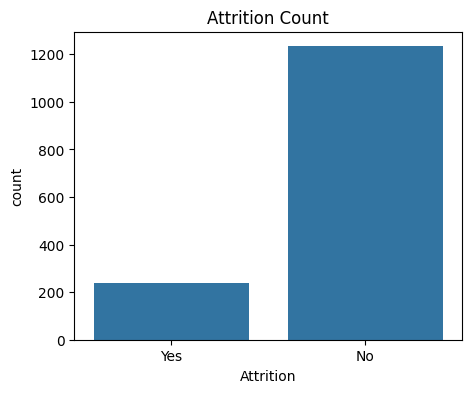

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="Attrition")
plt.title("Attrition Count")
plt.show()

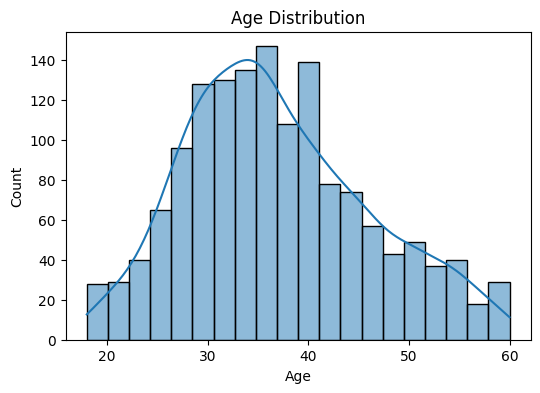

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20,kde=True)
plt.title("Age Distribution")
plt.show()

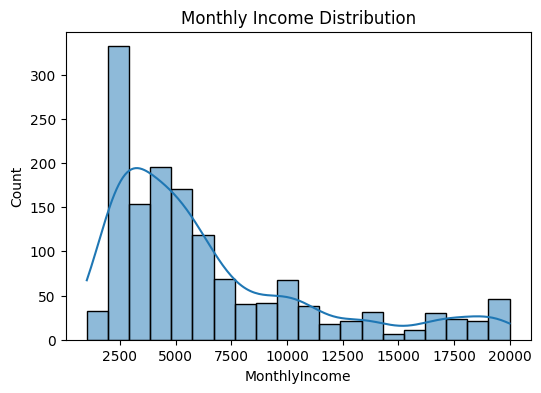

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyIncome"],bins=20,kde=True)
plt.title("Monthly Income Distribution")

plt.show()

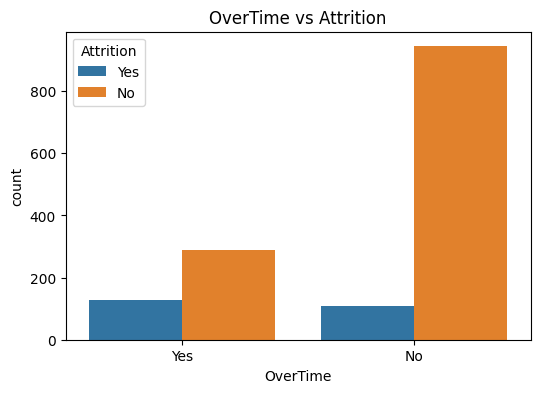

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="OverTime",hue="Attrition")
plt.title("OverTime vs Attrition")
plt.show()

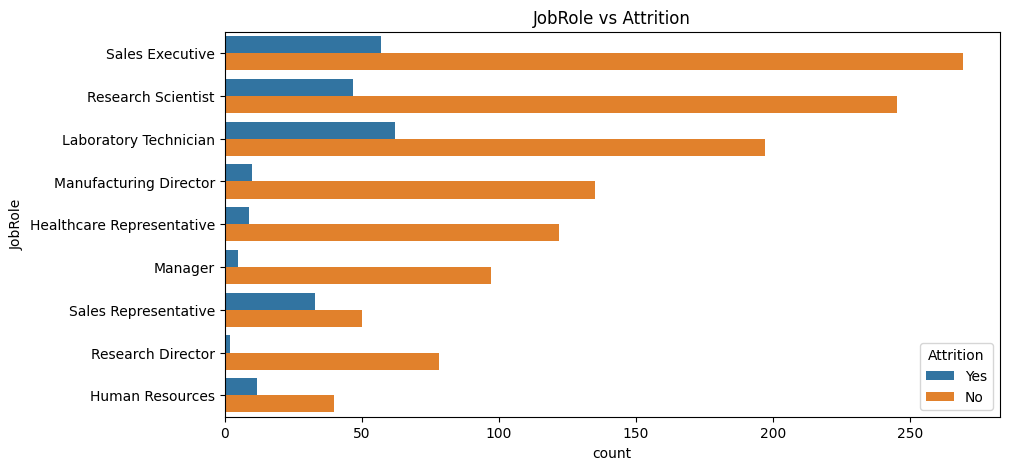

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,y="JobRole",hue="Attrition")
plt.title("JobRole vs Attrition")
plt.show()

Data Cleaning

In [24]:
df=df.drop_duplicates()
print(df.shape)

(1470, 17)


In [25]:
df.isnull().sum().sum()

np.int64(0)

#Encode Target

In [26]:
df["Attrition"]=df["Attrition"].map({"Yes":1,"No":0})

In [27]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


Feature Selection

In [28]:
X=df.drop("Attrition",axis=1)
y=df["Attrition"]

In [29]:
categorical=X.select_dtypes(include="object").columns
numerical=X.select_dtypes(exclude="object").columns

print(categorical)
print(numerical)

Index(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'OverTime'], dtype='object')
Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')


Preprocessing Pipeline

In [30]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
from sklearn.preprocessing import OneHotEncoder

preprocessor=ColumnTransformer([
    ("num",StandardScaler(),numerical),
    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical)
])

Train Test Split

In [32]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 16)
(294, 16)


In [33]:
# Apply Transformation in training set(fit_transform)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

Train Multiple Models

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [35]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    mode_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred)

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred)

    print(f"Model: {list(models.keys())[i]}")

    print("Training set performance")
    print("Accuracy: {:.4f}".format(mode_train_accuracy))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC: {:.4f}\n".format(model_test_roc_auc))

    print(y_test_pred[0])

Model: Logistic Regression
Training set performance
Accuracy: 0.8784
F1 Score: 0.4875
Precision: 0.7640
Recall: 0.3579
ROC AUC: 0.6683

Test set performance
Accuracy: 0.8639
F1 Score: 0.3750
Precision: 0.7059
Recall: 0.2553
ROC AUC: 0.6175

0
Model: Decision Tree
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.7789
F1 Score: 0.3564
Precision: 0.3333
Recall: 0.3830
ROC AUC: 0.6186

0
Model: Random Forest
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.8605
F1 Score: 0.3279
Precision: 0.7143
Recall: 0.2128
ROC AUC: 0.5983

0
Model: AdaBoost
Training set performance
Accuracy: 0.8844
F1 Score: 0.4925
Precision: 0.8462
Recall: 0.3474
ROC AUC: 0.6676

Test set performance
Accuracy: 0.8299
F1 Score: 0.2188
Precision: 0.4118
Recall: 0.1489
ROC AUC: 0.5542

1
Model: Gradient Boosting
Training set performance
A

there are 3 best model hyperparameter tuning XGBoost, Logistic Regression, and Random Forest

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

XGBoost Hyperparameter Tuning

In [38]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(xgb_grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best XGBoost CV F1 Score:
0.49967795417407174


Logistic Regression Hyperparameter Tuning

In [39]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("\nBest Logistic Regression CV F1 Score:")
print(lr_grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Logistic Regression Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}

Best Logistic Regression CV F1 Score:
0.48751334721121015


Random Forest Hyperparameter Tuning

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV F1 Score:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Random Forest Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Random Forest CV F1 Score:
0.4731258261103507


Compare the 3 Tuned Models

In [41]:
best_models = {
    "XGBoost": xgb_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Test Accuracy:",
          round(accuracy_score(y_test, y_pred), 4))

    print("Test Precision:",
          round(precision_score(y_test, y_pred), 4))

    print("Test Recall:",
          round(recall_score(y_test, y_pred), 4))

    print("Test F1 Score:",
          round(f1_score(y_test, y_pred), 4))

    print("Test ROC-AUC:",
          round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4))


XGBoost
Test Accuracy: 0.8639
Test Precision: 0.7059
Test Recall: 0.2553
Test F1 Score: 0.375
Test ROC-AUC: 0.7691

Logistic Regression
Test Accuracy: 0.7551
Test Precision: 0.3529
Test Recall: 0.6383
Test F1 Score: 0.4545
Test ROC-AUC: 0.7658

Random Forest
Test Accuracy: 0.8503
Test Precision: 0.5556
Test Recall: 0.3191
Test F1 Score: 0.4054
Test ROC-AUC: 0.7845


In [42]:
results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:, 1]
        )
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(
    by="F1 Score",
    ascending=False
))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1  Logistic Regression  0.755102   0.352941  0.638298  0.454545  0.765785
2        Random Forest  0.850340   0.555556  0.319149  0.405405  0.784478
0              XGBoost  0.863946   0.705882  0.255319  0.375000  0.769145


In [46]:
# Final Model
best_model = lr_grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.76       294
   macro avg       0.64      0.71      0.65       294
weighted avg       0.83      0.76      0.78       294



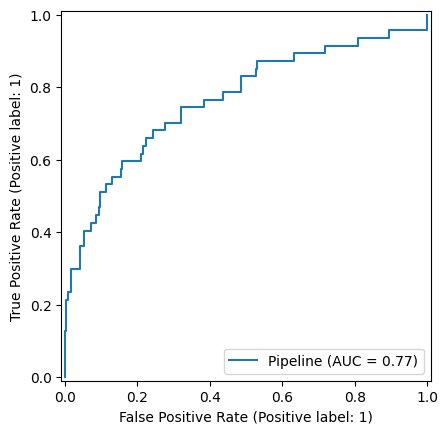

In [49]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

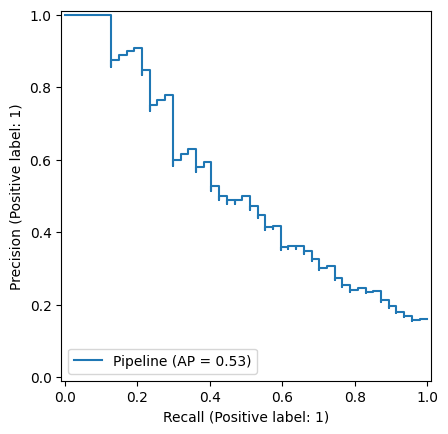

In [48]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

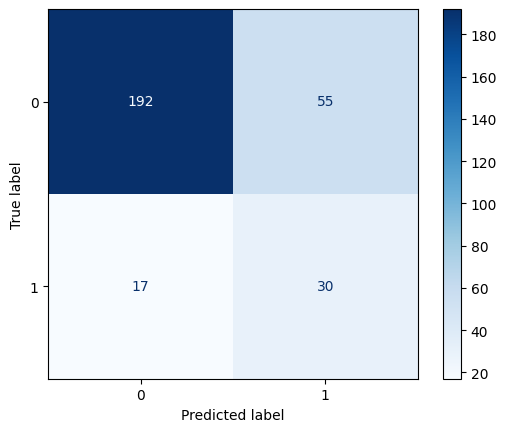

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap="Blues")
plt.show()

In [51]:
import sklearn
import joblib

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

best_model = lr_grid.best_estimator_

joblib.dump(
    best_model,
    "employee_attrition_model.pkl"
)

print("Final model saved successfully!")

scikit-learn: 1.6.1
joblib: 1.5.3
Final model saved successfully!


In [54]:
test_model = joblib.load("employee_attrition_model.pkl")

print("Model loaded successfully!")
print(test_model)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'OverTime'], dtype='object'))])),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])


In [55]:
import pandas as pd

# Test data
test_data = pd.DataFrame([{
    "Age": 22,
    "DistanceFromHome": 25,
    "Education": 1,
    "EnvironmentSatisfaction": 1,
    "JobLevel": 1,
    "JobSatisfaction": 1,
    "MonthlyIncome": 2000,
    "StockOptionLevel": 0,
    "TotalWorkingYears": 1,
    "WorkLifeBalance": 1,
    "YearsAtCompany": 1,
    "BusinessTravel": "Travel_Frequently",
    "Department": "Sales",
    "JobRole": "Sales Representative",
    "MaritalStatus": "Single",
    "OverTime": "Yes"
}])

# Prediction
prediction = best_model.predict(test_data)

print("Prediction:", prediction[0])

Prediction: 1
